# UCI Bank Marketing Dataset - Exploratory Data Analysis (EDA)

Welcome to the **UCI Bank Marketing Machine Learning Project**!

### Objective:
The goal of this project is to predict whether a bank client will subscribe to a term deposit (`y = yes / no`) based on marketing campaign phone calls and client demographic data.

### Dataset Details:
- **Source**: [UCI Machine Learning Repository (ID 222)](https://archive.ics.uci.edu/dataset/222/bank+marketing)
- **Features**: Client demographics (`age`, `job`, `marital`, `education`), financial history (`default`, `balance`, `housing`, `loan`), campaign contact info (`contact`, `day`, `month`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`).
- **Target**: `y` (binary: `'yes'` or `'no'`)

In [1]:
# 1. Setup paths and imports
import sys
from pathlib import Path

# Ensure project root is in sys.path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
%matplotlib inline

from src.data.load_data import load_bank_marketing_data
print("Imports successful!")

Imports successful!


In [2]:
# 2. Load the dataset (cached automatically to data/raw/)
X, y = load_bank_marketing_data()
df = X.copy()
df['target'] = y

print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Features: {X.shape[1]}")
df.head()

[2026-09-10 13:55:21] [INFO] src.data.load_data: Loading cached dataset from C:\Users\usasl\PycharmProjects\uci_banking_ML_project\data\raw\bank_features.csv and C:\Users\usasl\PycharmProjects\uci_banking_ML_project\data\raw\bank_targets.csv
Total Rows: 45,211
Total Features: 16


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


C:\Users\usasl\AppData\Local\Temp\ipykernel_32436\2228652511.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


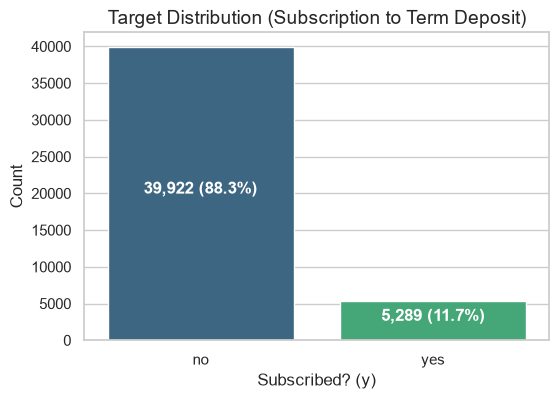

In [3]:
# 3. Target Distribution (Class Imbalance Check)
counts = df['target'].value_counts()
percentages = df['target'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Target Distribution (Subscription to Term Deposit)", fontsize=14)
plt.xlabel("Subscribed? (y)")
plt.ylabel("Count")

for i, p in enumerate(percentages):
    ax.annotate(f"{counts.iloc[i]:,} ({p:.1f}%)", (i, counts.iloc[i] / 2), ha='center', color='white', fontweight='bold')
plt.show()

In [4]:
# 4. Summary Statistics for Numeric Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
df[numeric_cols].describe()

Numeric columns (7): ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']


,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [5]:
# 5. Check Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct})
missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Percentage (%)
job,288,0.637013
education,1857,4.107407
contact,13020,28.798301
poutcome,36959,81.747805


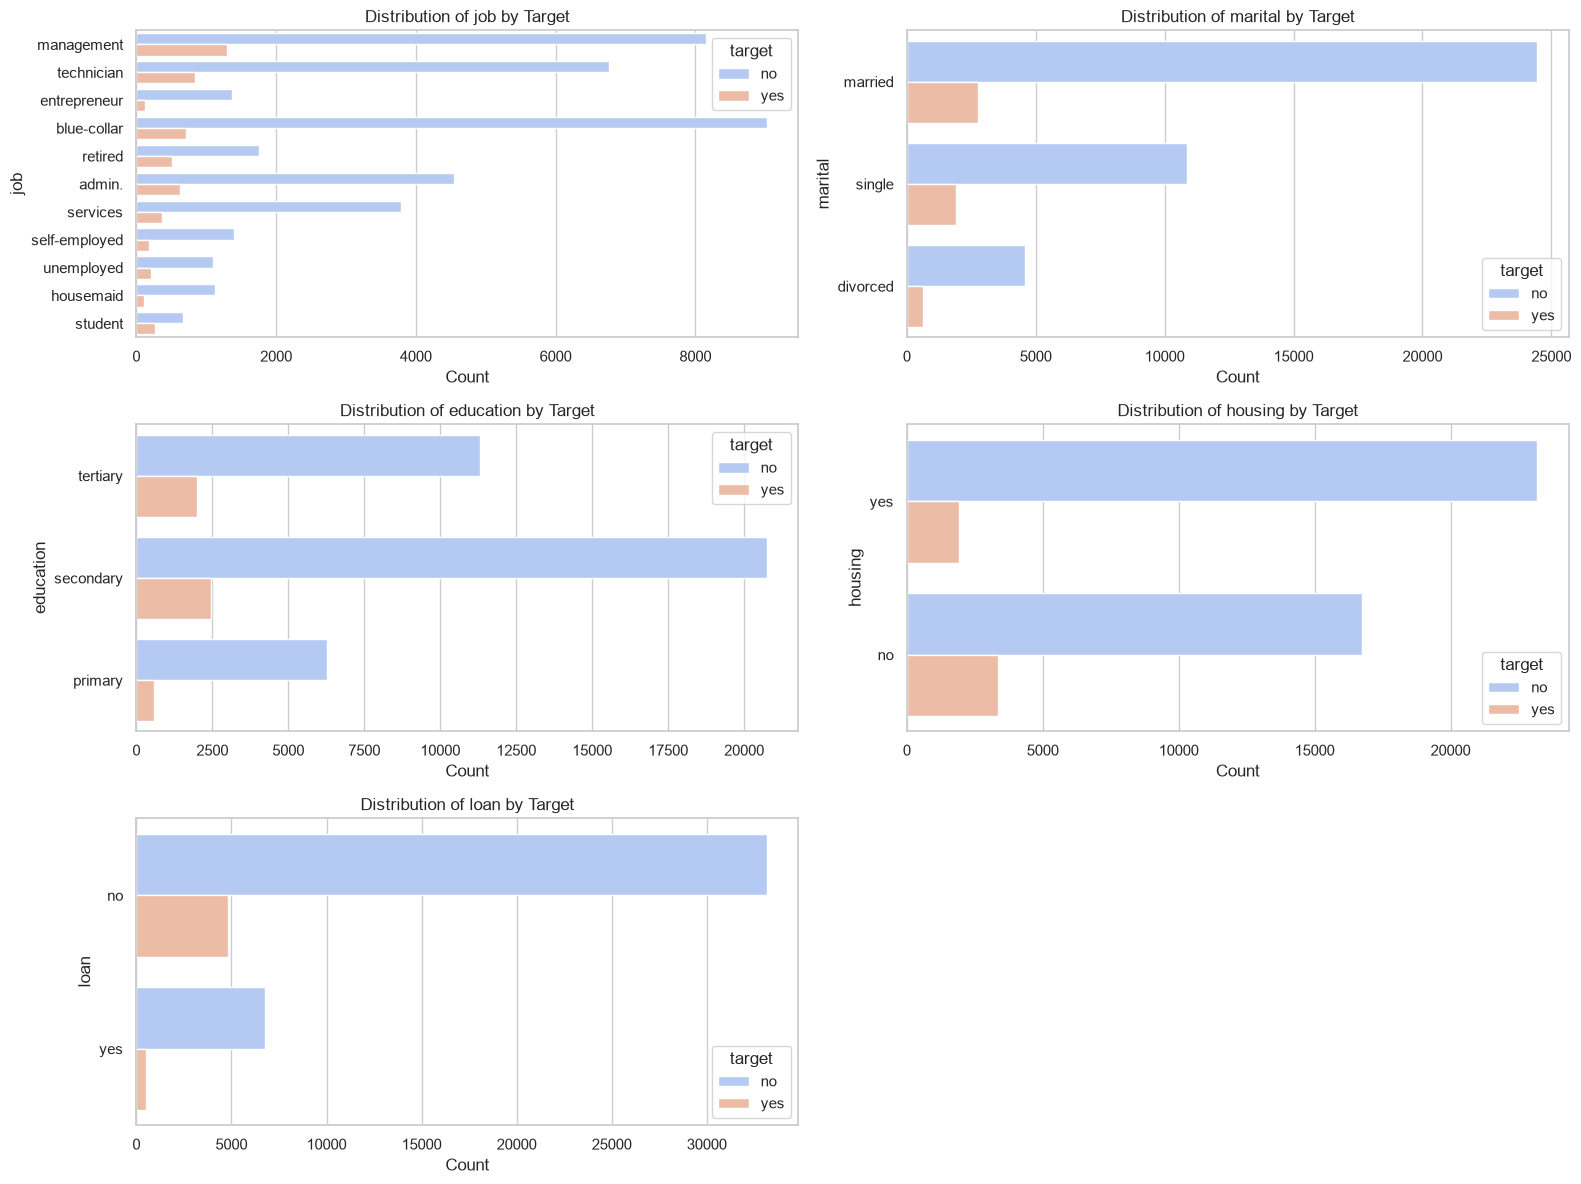

In [6]:
# 6. Categorical Features Distribution
cat_cols = ['job', 'marital', 'education', 'housing', 'loan']

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, hue='target', ax=axes[idx], palette="coolwarm")
    axes[idx].set_title(f"Distribution of {col} by Target")
    axes[idx].set_xlabel("Count")
    axes[idx].set_ylabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### Key Takeaways & Next Steps:
1. **Imbalanced Target**: Term deposit subscriptions are only ~11.7% of all contacts. Metrics like **Precision, Recall, F1-Score, and ROC-AUC** are much more informative than simple Accuracy.
2. **Data Pipeline**: Preprocessing will use `ColumnTransformer` with `StandardScaler` for numeric columns and `OneHotEncoder` for categorical columns.
3. **Models**: Test baseline Logistic Regression with `class_weight='balanced'`, followed by ensemble models (Random Forest, Gradient Boosting).

To run the baseline models now, run in terminal:
```bash
python -m src.models.train
```